# Data inventory and quality — final experiments

Decision support for Workstream 1 / Gate F1 in `final_experiments/plan.html`.

**Question.** Do we already have enough news and prices to run the closing
experiments, and is the quality good enough — or do we need to gather more?

**What this notebook does.** Inventory both candidate spines against the
plan's "Data To Gather" table, measure coverage and quality (no modelling),
profile the FNSPID earnings calendar gathered via LSEG, and end with an
explicit keep / restore / collect decision checklist.

**What it does not do.** Build the firm-day panel, score returns, or choose
the research question. Licensed LSEG/FNSPID headline and body text is never
printed.

Candidate spines (from the plan — not pooled):

| Spine | Role | Window | Scale claimed in plan |
| --- | --- | --- | --- |
| A — FNSPID | Breadth and history | 2011–2023 coherent cohort | 574 firms, ~1.64M firm events |
| B — LSEG | Recency and body text | sector-33 (6m) + midcap-22 (1y) | 710k / 2.6k headlines |

## 1. Setup

In [1]:
from __future__ import annotations

import json
import re
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from the repository root or from final_experiments/")

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "00_data_inventory"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: Any) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

print(f"repo root: {REPO_ROOT}")
print(f"outputs:   {OUTPUT_DIR}")

repo root: /Users/peterprendergast/Documents/Sentiment_Dissertation
outputs:   /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/00_data_inventory


## 2. Paths the plan expects

In [2]:
FNSPID_RAW = Path(
    "/Users/peterprendergast/Documents/Sentiment_Dissertation_data"
    "/FNSPID/bf9189c41527198897d1af3e17b1a0095279fc45/raw"
)
FNSPID_GATE = (
    REPO_ROOT / "reports" / "fnspid_feasibility_20260718" / "gate1_revised_authoritative"
)

SECTOR_ROOT = REPO_ROOT / "Data" / "collections" / "lseg_us_sector_33_6m"
MIDCAP_ROOT = REPO_ROOT / "Data" / "collections" / "lseg_us_midcap_22_1y"
PRICES = REPO_ROOT / "Data" / "derived" / "prices"
EARNINGS_DIR = REPO_ROOT / "final_experiments" / "data" / "earnings"
FNSPID_COHORT = REPO_ROOT / "reports" / "loop_vader_scale_20260719" / "cohort_symbols.csv"

PATHS: dict[str, Path] = {
    "fnspid_download_manifest": FNSPID_RAW / "download_manifest.json",
    "fnspid_all_external": FNSPID_RAW / "Stock_news" / "All_external.csv.zst",
    "fnspid_nasdaq_external": FNSPID_RAW / "Stock_news" / "nasdaq_exteral_data.csv.zst",
    "fnspid_prices_zip": FNSPID_RAW / "Stock_price" / "full_history.zip",
    "fnspid_gate_source_audit": FNSPID_GATE / "source_timestamp_audit.csv",
    "fnspid_gate_coverage_breaks": FNSPID_GATE / "coverage_breaks.csv",
    "fnspid_gate_symbol_year": FNSPID_GATE / "symbol_year_coverage.csv",
    "fnspid_gate_daily_counts": FNSPID_GATE / "daily_event_counts.csv",
    "fnspid_gate_candidate_windows": FNSPID_GATE / "candidate_windows.csv",
    "fnspid_cohort_symbols": FNSPID_COHORT,
    "sector_headlines": SECTOR_ROOT / "derived" / "us_sector_33_6m" / "csv" / "headlines.csv",
    "sector_bodies": SECTOR_ROOT / "derived" / "us_sector_33_6m" / "csv" / "main_bodies.csv",
    "sector_csv_manifest": SECTOR_ROOT / "derived" / "us_sector_33_6m" / "csv" / "manifest.json",
    "sector_raw_manifest": SECTOR_ROOT / "raw" / "lseg_us_sector_33_6m" / "manifest.json",
    "sector_derived_manifest": SECTOR_ROOT / "derived" / "us_sector_33_6m" / "manifest.json",
    "sector_scores": (
        SECTOR_ROOT
        / "derived"
        / "headline_scores_finbert4556_vader_baseline_v1_cacheonly_20260722.csv"
    ),
    "sector_quality_audit": SECTOR_ROOT / "reports" / "clean_csv_quality_audit.md",
    "midcap_articles": MIDCAP_ROOT / "derived" / "us_midcap_22_1y" / "articles.jsonl",
    "midcap_manifest": MIDCAP_ROOT / "derived" / "us_midcap_22_1y" / "manifest.json",
    "midcap_scores": (
        MIDCAP_ROOT
        / "derived"
        / "headline_scores_finbert4556_vader_baseline_v1_cacheonly_20260718.csv"
    ),
    "prices_sector": PRICES / "lseg_us_sector_33_strategy_adjusted_open.csv",
    "prices_midcap": PRICES / "lseg_us_midcap_22_strategy_adjusted_open.csv",
    "prices_sp500": PRICES / "lseg_sp500_20250620_20260710.csv",
    "earnings_raw": EARNINGS_DIR / "earnings_events_raw.csv",
    "earnings_quarterly": EARNINGS_DIR / "fnspid_earnings_calendar_2011_2023_quarterly.csv",
    "earnings_all": EARNINGS_DIR / "fnspid_earnings_calendar_2011_2023.csv",
    "earnings_manifest": EARNINGS_DIR / "manifest.json",
    "earnings_ric_map": EARNINGS_DIR / "symbol_ric_map.csv",
    "earnings_rejected": EARNINGS_DIR / "earnings_events_title_rejected.csv",
    "earnings_license": EARNINGS_DIR / "license_record.md",
}


@dataclass
class AssetStatus:
    key: str
    path: str
    exists: bool
    size_bytes: int | None
    note: str = ""


def _status(key: str, path: Path, note: str = "") -> AssetStatus:
    exists = path.exists()
    size = path.stat().st_size if exists else None
    return AssetStatus(key=key, path=str(path), exists=exists, size_bytes=size, note=note)


inventory = pd.DataFrame([_status(k, p).__dict__ for k, p in PATHS.items()])
inventory["size_mb"] = inventory["size_bytes"].map(
    lambda x: None if x is None else round(x / 1e6, 1)
)
missing = inventory.loc[~inventory["exists"], "key"].tolist()
print(f"tracked assets: {len(inventory)}  missing: {len(missing)}")
if missing:
    print("MISSING:", ", ".join(missing))
display(inventory[["key", "exists", "size_mb", "path"]])

tracked assets: 30  missing: 0


,key,exists,size_mb,path
0,fnspid_download_manifest,True,0.0,/Users/peterprendergast/Documents/Sentiment_Di...
1,fnspid_all_external,True,1487.1,/Users/peterprendergast/Documents/Sentiment_Di...
2,fnspid_nasdaq_external,True,4368.7,/Users/peterprendergast/Documents/Sentiment_Di...
3,fnspid_prices_zip,True,589.5,/Users/peterprendergast/Documents/Sentiment_Di...
4,fnspid_gate_source_audit,True,0.0,/Users/peterprendergast/Documents/Sentiment_Di...
5,fnspid_gate_coverage_breaks,True,0.0,/Users/peterprendergast/Documents/Sentiment_Di...
6,fnspid_gate_symbol_year,True,0.9,/Users/peterprendergast/Documents/Sentiment_Di...
7,fnspid_gate_daily_counts,True,0.1,/Users/peterprendergast/Documents/Sentiment_Di...
8,fnspid_gate_candidate_windows,True,0.0,/Users/peterprendergast/Documents/Sentiment_Di...
9,fnspid_cohort_symbols,True,0.0,/Users/peterprendergast/Documents/Sentiment_Di...


## 3. Plan "Data To Gather" checklist — live status

In [3]:
earnings_hits = list((REPO_ROOT / "Data").rglob("*"))
earnings_name_hits = [
    p
    for p in earnings_hits
    if any(tok in p.name.lower() for tok in ("earnings_date", "earnings_calendar", "earnings"))
    and p.is_file()
    and "earnings_guidance" not in p.name.lower()
]
# Narrower: files whose *name* looks like a calendar artifact.
calendar_like = [
    p
    for p in earnings_name_hits
    if any(tok in p.name.lower() for tok in ("calendar", "earnings_date", "report_date"))
]

sector_mapping_explicit = list((REPO_ROOT / "Data").rglob("*sector*map*")) + list(
    (REPO_ROOT / "Data").rglob("*industry*")
)
label_templates = list((REPO_ROOT / "Data").rglob("sample_label_template.csv"))
labelled_templates = []
for p in label_templates:
    try:
        tmp = pd.read_csv(p)
        # A useful labelled file has a non-empty human label column.
        label_cols = [c for c in tmp.columns if "label" in c.lower()]
        if label_cols and tmp[label_cols].notna().any().any():
            labelled_templates.append(p)
    except Exception:
        continue

gather_rows = [
    {
        "item": "Scheduled earnings calendar",
        "plan_status": "FNSPID via LSEG gathered; LSEG names still open",
        "observed": (
            f"Present: {PATHS['earnings_quarterly'].relative_to(REPO_ROOT)} "
            f"({PATHS['earnings_quarterly'].stat().st_size / 1e6:.1f} MB)"
            if PATHS["earnings_quarterly"].exists()
            else (
                "No calendar-like file under Data/"
                if not calendar_like
                else f"Possible hits: {[str(p.relative_to(REPO_ROOT)) for p in calendar_like[:5]]}"
            )
        ),
        "blocks": "Workstream 6 (validation still open)",
        "need_more": not PATHS["earnings_quarterly"].exists(),
    },
    {
        "item": "FNSPID archives",
        "plan_status": "Local-only; re-verify hashes",
        "observed": (
            "All three archives present with byte sizes matching download_manifest.json"
            if PATHS["fnspid_all_external"].exists()
            and PATHS["fnspid_nasdaq_external"].exists()
            and PATHS["fnspid_prices_zip"].exists()
            else "Archives missing or incomplete — restore/re-download"
        ),
        "blocks": "Spine A panel",
        "need_more": not (
            PATHS["fnspid_all_external"].exists()
            and PATHS["fnspid_nasdaq_external"].exists()
            and PATHS["fnspid_prices_zip"].exists()
        ),
    },
    {
        "item": "Sector / industry mapping",
        "plan_status": "Only implicit in sector-33 config",
        "observed": (
            f"No explicit mapping table found ({len(sector_mapping_explicit)} loose hits)"
            if len(sector_mapping_explicit) < 1
            else f"Candidate files: {[str(p.relative_to(REPO_ROOT)) for p in sector_mapping_explicit[:5]]}"
        ),
        "blocks": "Per-sector thresholds; sector-day demeaning",
        "need_more": True,
    },
    {
        "item": "Market benchmark returns",
        "plan_status": "lseg_sp500_*.csv present; FNSPID used SPY",
        "observed": (
            f"Present: {PATHS['prices_sp500'].name}"
            if PATHS["prices_sp500"].exists()
            else "Missing SP500 derived CSV"
        ),
        "blocks": "Surprise / market model",
        "need_more": not PATHS["prices_sp500"].exists(),
    },
    {
        "item": "Wider LSEG collection (optional)",
        "plan_status": "Not collected; sector-33 left bodies unfetched",
        "observed": "Only sector-33 + midcap-22 on disk",
        "blocks": "Only if Spine B is primary and needs more power",
        "need_more": None,  # decision-dependent
    },
    {
        "item": "Human audit labels",
        "plan_status": "Templates exist; labels empty",
        "observed": (
            f"{len(label_templates)} template(s); {len(labelled_templates)} with any labels filled"
        ),
        "blocks": "Filter precision (WS2); event-type validity (WS5)",
        "need_more": len(labelled_templates) == 0,
    },
    {
        "item": "Corporate-action metadata",
        "plan_status": "Absent; prices split-adj only",
        "observed": "No corporate-action table under Data/ (known limitation)",
        "blocks": "Not blocking — document limitation",
        "need_more": False,
    },
]
gather = pd.DataFrame(gather_rows)
display(gather)
gather.to_csv(OUTPUT_DIR / "data_to_gather_status.csv", index=False)

,item,plan_status,observed,blocks,need_more
0,Scheduled earnings calendar,FNSPID via LSEG gathered; LSEG names still open,Present: final_experiments/data/earnings/fnspi...,Workstream 6 (validation still open),False
1,FNSPID archives,Local-only; re-verify hashes,All three archives present with byte sizes mat...,Spine A panel,False
2,Sector / industry mapping,Only implicit in sector-33 config,No explicit mapping table found (0 loose hits),Per-sector thresholds; sector-day demeaning,True
3,Market benchmark returns,lseg_sp500_*.csv present; FNSPID used SPY,Present: lseg_sp500_20250620_20260710.csv,Surprise / market model,False
4,Wider LSEG collection (optional),Not collected; sector-33 left bodies unfetched,Only sector-33 + midcap-22 on disk,Only if Spine B is primary and needs more power,None
5,Human audit labels,Templates exist; labels empty,8 template(s); 0 with any labels filled,Filter precision (WS2); event-type validity (WS5),True
6,Corporate-action metadata,Absent; prices split-adj only,No corporate-action table under Data/ (known l...,Not blocking — document limitation,False


## 4. Spine A — FNSPID (breadth / history)

We do **not** re-stream the multi-GB archives here. Coverage quality is read
from the revised Gate 1 aggregates already frozen under
`reports/fnspid_feasibility_20260718/gate1_revised_authoritative/`. Archive
byte sizes are checked against the download manifest.

In [4]:
fnspid_archive_check = []
if PATHS["fnspid_download_manifest"].exists():
    mani = json.loads(PATHS["fnspid_download_manifest"].read_text())
    for entry in mani["files"]:
        p = Path(entry["local_path"])
        ok = p.exists() and p.stat().st_size == entry["local_size_bytes"]
        fnspid_archive_check.append(
            {
                "upstream_path": entry["upstream_path"],
                "exists": p.exists(),
                "size_match": ok,
                "local_mb": round(p.stat().st_size / 1e6, 1) if p.exists() else None,
                "expected_mb": round(entry["local_size_bytes"] / 1e6, 1),
                "upstream_sha256_prefix": entry["upstream_sha256"][:12],
            }
        )
    display(pd.DataFrame(fnspid_archive_check))
    print(
        "Note: size match confirms the files on disk match the download receipt. "
        "Re-hashing multi-GB archives is skipped here; re-run scripts/download_fnspid.py "
        "verification if promoting Spine A into the dissertation."
    )
else:
    print("FNSPID download manifest missing — cannot verify archives.")

,upstream_path,exists,size_match,local_mb,expected_mb,upstream_sha256_prefix
0,Stock_news/All_external.csv,True,True,1487.1,1487.1,5d4c018036bd
1,Stock_news/nasdaq_exteral_data.csv,True,True,4368.7,4368.7,1a7a3eb8e6b9
2,Stock_price/full_history.zip,True,True,589.5,589.5,03da4fce7ebe


Note: size match confirms the files on disk match the download receipt. Re-hashing multi-GB archives is skipped here; re-run scripts/download_fnspid.py verification if promoting Spine A into the dissertation.


,source_site,rows,rows_with_nonempty_symbol,full_datetime_rows,full_datetime_rows_with_nonempty_symbol,date_only_or_exact_midnight_rows,invalid_timestamp_rows,full_datetime_fraction,mappable_deduplicated_firm_events
12,reuters.com,17112620,0,17091322,0,21298,0,0.998755,0
0,benzinga.com,3058574,3058574,111974,111974,2946600,0,0.036610,1529285
10,nasdaq.com,2491785,2491785,26623,26623,2465162,0,0.010684,2488577
13,seekingalpha.com,1794438,1794438,0,0,1794438,0,0.000000,892323
6,lenta.ru,1601950,0,0,0,1601950,0,0.000000,0
1,bloomberg.com,893156,0,0,0,893156,0,0.000000,0
20,zacks.com,859118,859118,0,0,859118,0,0.000000,427974
4,gurufocus.com,387328,387328,0,0,387328,0,0.000000,192383
11,news.investors.com,135110,135110,0,0,135110,0,0.000000,66844
5,investors.com,125442,125442,0,0,125442,0,0.000000,62344


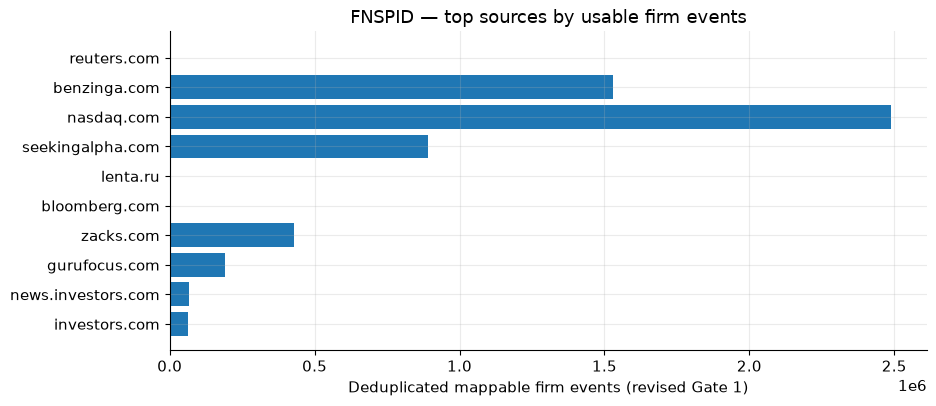

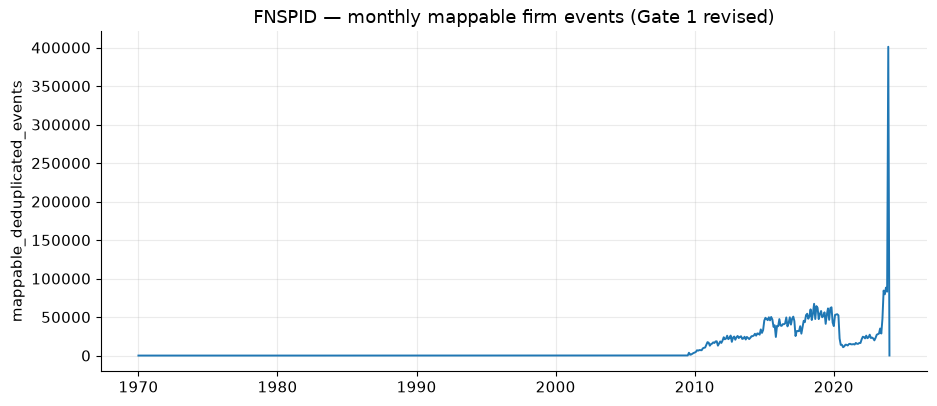

daily file: 3,681 rows; monthly range 1970-01-01 → 2024-01-01
documented >3× source-month breaks: 60


,source_site,previous_month,month,previous_count,count,max_fold_change
0,benzinga.com,2009-02,2009-03,1,0,inf
1,benzinga.com,2009-03,2009-04,0,3,inf
2,benzinga.com,2009-05,2009-06,7,42,6.000000
3,benzinga.com,2009-07,2009-08,78,3593,46.064103
4,benzinga.com,2009-08,2009-09,3593,1031,3.484966
5,foxbusiness.com,2016-01,2016-02,19,0,inf
6,foxbusiness.com,2017-03,2017-04,0,1,inf
7,foxbusiness.com,2017-04,2017-05,1,8,8.000000


,start_year,end_year,years,minimum_eligible_firms_in_any_year,firms_eligible_in_every_year,total_mappable_deduplicated_events,coherent_firm_mappable_events,dimension_gate_pass
97,2009,2014,6,36,34,1192134,53104,False
98,2019,2024,6,0,0,2403203,0,False
99,2009,2013,5,36,34,857537,42922,False
100,2020,2024,5,0,0,1765370,0,False
101,2009,2012,4,36,34,578746,32058,False
102,2021,2024,4,0,0,1414396,0,False
103,2009,2011,3,36,36,309905,22671,False
104,2022,2024,3,0,0,1233114,0,False


gate_decision                PASS under revised next-session timing (see re...
physical_rows                                                         28606813
symbol_rows                                                            8997559
deduplicated_firm_events                                               5730630
distinct_symbols                                                          8552
coherent_2011_2023_firms                                                   574
coherent_2011_2023_events                                              1641283
source_regime_breaks_gt3x                                                   60
reuters_rows_with_symbol                                                     0
license                                                           CC BY-NC 4.0
Name: fnspid_plan_vs_gate, dtype: object

In [5]:
fnspid_summary = {
    "gate_decision": "PASS under revised next-session timing (see revised_timing_addendum.md)",
    "physical_rows": 28_606_813,
    "symbol_rows": 8_997_559,
    "deduplicated_firm_events": 5_730_630,
    "distinct_symbols": 8_552,
    "coherent_2011_2023_firms": 574,
    "coherent_2011_2023_events": 1_641_283,
    "source_regime_breaks_gt3x": 60,
    "reuters_rows_with_symbol": 0,
    "license": "CC BY-NC 4.0",
}

if PATHS["fnspid_gate_source_audit"].exists():
    src = pd.read_csv(PATHS["fnspid_gate_source_audit"])
    src = src.sort_values("rows", ascending=False)
    display(src.head(12))

    fig, ax = plt.subplots()
    top = src.head(10).iloc[::-1]
    ax.barh(top["source_site"], top["mappable_deduplicated_firm_events"])
    ax.set_xlabel("Deduplicated mappable firm events (revised Gate 1)")
    ax.set_title("FNSPID — top sources by usable firm events")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fnspid_top_sources.png", dpi=140)
    plt.show()

if PATHS["fnspid_gate_daily_counts"].exists():
    daily = pd.read_csv(PATHS["fnspid_gate_daily_counts"])
    # Flexible column detection across audit schemas.
    date_col = next(c for c in daily.columns if "date" in c.lower() or c == "day")
    count_col = next(
        c
        for c in daily.columns
        if c not in {date_col} and pd.api.types.is_numeric_dtype(daily[c])
    )
    daily[date_col] = pd.to_datetime(daily[date_col])
    monthly = daily.set_index(date_col)[count_col].resample("MS").sum()
    fig, ax = plt.subplots()
    ax.plot(monthly.index, monthly.values, lw=1.4)
    ax.set_title("FNSPID — monthly mappable firm events (Gate 1 revised)")
    ax.set_ylabel(count_col)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fnspid_monthly_events.png", dpi=140)
    plt.show()
    print(
        f"daily file: {len(daily):,} rows; monthly range "
        f"{monthly.index.min().date()} → {monthly.index.max().date()}"
    )

if PATHS["fnspid_gate_coverage_breaks"].exists():
    breaks = pd.read_csv(PATHS["fnspid_gate_coverage_breaks"])
    print(f"documented >3× source-month breaks: {len(breaks)}")
    display(breaks.head(8))

if PATHS["fnspid_gate_candidate_windows"].exists():
    windows = pd.read_csv(PATHS["fnspid_gate_candidate_windows"])
    display(windows.tail(8))

display(pd.Series(fnspid_summary, name="fnspid_plan_vs_gate"))

### Spine A quality read

- **Strength.** Long window, hundreds of coherent firms, millions of events —
  enough date clusters for surprise, aggregation, and threshold learning.
- **Weakness.** Almost all usable events are date-only (next-session mapping).
  Reuters contributes ~17M timed rows but **zero** supplied symbols. Publisher
  regime is unstable (60 >3× month breaks). Headline-only scrapes, no LSEG-style
  body text or `source_code` wire identity.
- **On disk today.** Archives present and size-matched. Gate aggregates present.
  Full re-hash and Gate 2 price validation are still outstanding per the plan.

## 5. Spine B — LSEG sector-33 (recency / bodies)

In [6]:
def _load_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text())


sector_raw = _load_json(PATHS["sector_raw_manifest"]) if PATHS["sector_raw_manifest"].exists() else {}
sector_csv = _load_json(PATHS["sector_csv_manifest"]) if PATHS["sector_csv_manifest"].exists() else {}
sector_derived = (
    _load_json(PATHS["sector_derived_manifest"]) if PATHS["sector_derived_manifest"].exists() else {}
)

sector_counts = {
    "window_start": sector_raw.get("config", {}).get("collection", {}).get("start"),
    "window_end": sector_raw.get("config", {}).get("collection", {}).get("end"),
    "n_companies_configured": len(sector_raw.get("config", {}).get("companies", [])),
    "raw_headlines": sector_raw.get("counts", {}).get("headlines"),
    "raw_stories_targeted_reuters": sector_raw.get("counts", {}).get("stories"),
    "successful_story_fetches": sector_raw.get("counts", {}).get("successful_stories"),
    "failed_stories": sector_raw.get("counts", {}).get("failed_stories"),
    "headlines_without_story_fetch": sector_raw.get("counts", {}).get(
        "headlines_without_story_fetch"
    ),
    "clean_headlines_csv": sector_csv.get("counts", {}).get("headlines", {}).get("written"),
    "clean_bodies_written": sector_csv.get("counts", {}).get("main_bodies", {}).get("written"),
    "body_ok": sector_csv.get("counts", {}).get("body_text_quality", {}).get("ok"),
    "body_boilerplate_only": sector_csv.get("counts", {})
    .get("body_text_quality", {})
    .get("boilerplate_only"),
}
display(pd.Series(sector_counts, name="sector_33_manifest_counts"))

window_start                     2025-12-26T00:00:00Z
window_end                       2026-06-26T00:00:00Z
n_companies_configured                             33
raw_headlines                                  710625
raw_stories_targeted_reuters                    23191
successful_story_fetches                        23183
failed_stories                                      8
headlines_without_story_fetch                  687434
clean_headlines_csv                            710625
clean_bodies_written                            17774
body_ok                                         17722
body_boilerplate_only                            5409
Name: sector_33_manifest_counts, dtype: object

In [7]:
# Metadata-only load — never read the headline text column.
hl_usecols = [
    "revision_id",
    "story_id",
    "story_family_id",
    "version_created",
    "source_code",
    "matched_symbols",
    "headline_sha256",
]
hl = pd.read_csv(PATHS["sector_headlines"], usecols=hl_usecols)
hl["version_created"] = pd.to_datetime(hl["version_created"], utc=True, format="ISO8601")
hl["source_code"] = hl["source_code"].astype("category")
hl["date"] = hl["version_created"].dt.tz_convert("America/New_York").dt.normalize()

# Firm associations (pipe-joined).
firm_rows = (
    hl.assign(symbol=hl["matched_symbols"].fillna("").str.split("|"))
    .explode("symbol")
    .loc[lambda d: d["symbol"].astype(str).str.len() > 0]
    .copy()
)
firm_rows["symbol"] = firm_rows["symbol"].astype("category")

n_sources = hl["source_code"].nunique()
reuters_share = float((hl["source_code"] == "NS:RTRS").mean())
n_families = hl["story_family_id"].nunique()
revisions_per_family = len(hl) / max(n_families, 1)

firm_day = (
    firm_rows.groupby(["symbol", "date"], observed=True)
    .agg(
        n_headlines=("revision_id", "nunique"),
        n_families=("story_family_id", "nunique"),
        n_sources=("source_code", "nunique"),
    )
    .reset_index()
)

coverage = pd.Series(
    {
        "headline_revisions": len(hl),
        "unique_story_families": n_families,
        "mean_revisions_per_family": round(revisions_per_family, 2),
        "distinct_source_codes": n_sources,
        "reuters_share_of_headlines": round(reuters_share, 4),
        "firm_associations": len(firm_rows),
        "unique_symbols_in_news": firm_rows["symbol"].nunique(),
        "firm_days": len(firm_day),
        "median_headlines_per_firm_day": float(firm_day["n_headlines"].median()),
        "p90_headlines_per_firm_day": float(firm_day["n_headlines"].quantile(0.9)),
        "share_firm_days_n1": float((firm_day["n_headlines"] == 1).mean()),
        "share_firm_days_n_ge_20": float((firm_day["n_headlines"] >= 20).mean()),
        "date_min_ny": str(firm_rows["date"].min().date()),
        "date_max_ny": str(firm_rows["date"].max().date()),
        "n_calendar_days_with_news": firm_rows["date"].nunique(),
    },
    name="sector_33_coverage",
)
display(coverage)

headline_revisions                   710625
unique_story_families                704696
mean_revisions_per_family              1.01
distinct_source_codes                  2854
reuters_share_of_headlines           0.0326
firm_associations                    739242
unique_symbols_in_news                   33
firm_days                              6016
median_headlines_per_firm_day          76.0
p90_headlines_per_firm_day            292.5
share_firm_days_n1                 0.003324
share_firm_days_n_ge_20            0.862699
date_min_ny                      2025-12-25
date_max_ny                      2026-06-25
n_calendar_days_with_news               183
Name: sector_33_coverage, dtype: object

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_20421/2812025695.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hl.assign(month=hl["version_created"].dt.to_period("M").dt.to_timestamp())


,source_code,n,share
0,NS:GLORDP,113682,0.159975
1,NS:X,49635,0.069847
2,NS:EDG,34786,0.048951
3,NS:NEWNYS,23678,0.033320
4,NS:RTRS,23191,0.032635
5,NS:CNBSTR,21426,0.030151
6,NS:YAHNEX,19953,0.028078
7,NS:GLOWEE,17865,0.025140
8,NS:NEWWIR,16918,0.023807
9,NS:SPONEW,14012,0.019718


/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_20421/2812025695.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_all = hl.groupby(hl["version_created"].dt.to_period("M")).size()


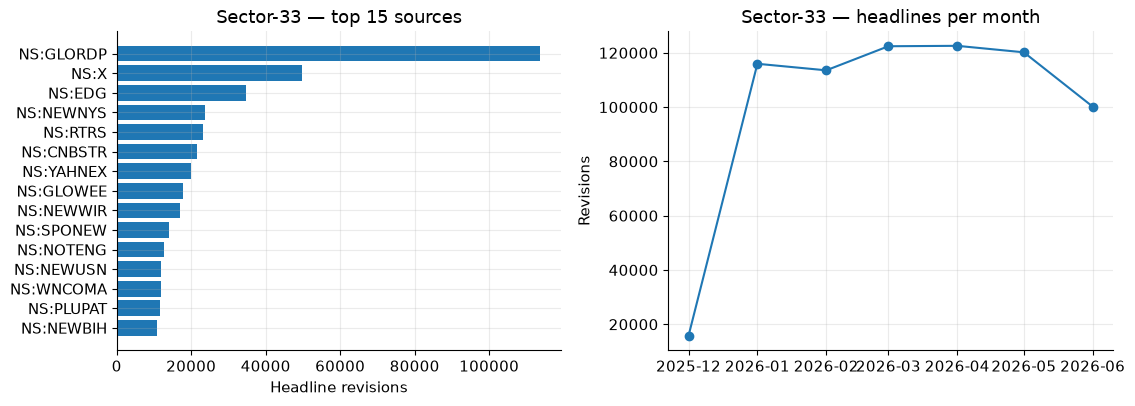

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_20421/2812025695.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  firm_rows.assign(month=firm_rows["date"].dt.to_period("M").dt.to_timestamp())


LSEG sector-33 symbol-months with >3× consecutive change: 33 (plan cited 239 across both LSEG cohorts)


,symbol,month,n,prev,fold
1,AAPL,2026-01-01,3430,404.0,8.490099
8,AMT,2026-01-01,1136,215.0,5.283721
15,AMZN,2026-01-01,6816,653.0,10.437979
22,BA,2026-01-01,3487,479.0,7.279749
29,BAC,2026-01-01,4571,727.0,6.287483
36,CAT,2026-01-01,1786,238.0,7.504202
43,COP,2026-01-01,1623,237.0,6.848101
50,CVX,2026-01-01,3597,326.0,11.033742
57,DUK,2026-01-01,1800,370.0,4.864865
64,EQIX,2026-01-01,1057,182.0,5.807692


In [8]:
# Source concentration and regime-break flags (plan: >3× consecutive monthly change).
src_month = (
    hl.assign(month=hl["version_created"].dt.to_period("M").dt.to_timestamp())
    .groupby(["source_code", "month"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
top_sources = (
    hl["source_code"].value_counts().head(15).rename_axis("source_code").reset_index(name="n")
)
top_sources["share"] = top_sources["n"] / len(hl)
display(top_sources)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].barh(top_sources["source_code"].astype(str)[::-1], top_sources["n"][::-1])
axes[0].set_title("Sector-33 — top 15 sources")
axes[0].set_xlabel("Headline revisions")

monthly_all = hl.groupby(hl["version_created"].dt.to_period("M")).size()
monthly_all.index = monthly_all.index.to_timestamp()
axes[1].plot(monthly_all.index, monthly_all.values, marker="o")
axes[1].set_title("Sector-33 — headlines per month")
axes[1].set_ylabel("Revisions")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sector33_sources_and_monthly.png", dpi=140)
plt.show()

# Symbol-month regime breaks: >3× consecutive change in firm-month headline count.
sym_month = (
    firm_rows.assign(month=firm_rows["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["symbol", "month"], observed=True)
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["symbol", "month"])
)
sym_month["prev"] = sym_month.groupby("symbol", observed=True)["n"].shift(1)
sym_month["fold"] = sym_month["n"] / sym_month["prev"].replace(0, np.nan)
breaks_lseg = sym_month.loc[sym_month["fold"].ge(3) | (1 / sym_month["fold"]).ge(3)].copy()
print(
    f"LSEG sector-33 symbol-months with >3× consecutive change: {len(breaks_lseg)} "
    f"(plan cited 239 across both LSEG cohorts)"
)
display(breaks_lseg.head(10))

,firm_days,headline_mass,share_firm_days,share_headline_mass
n_bin,,,,
1,20,20,0.003324,0.000027
2-5,143,522,0.023770,0.000706
6-20,695,8944,0.115525,0.012099
21-75,2115,102949,0.351562,0.139263
76+,3043,626807,0.505818,0.847905


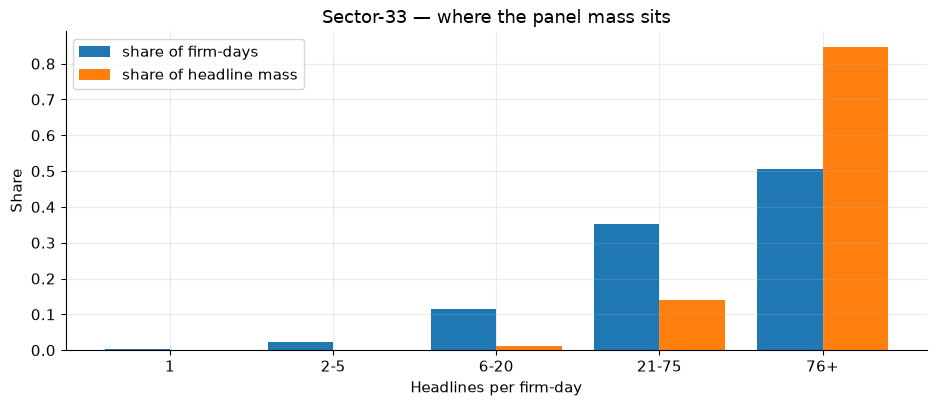

In [9]:
# Firm-day story-count distribution — the plan's low-n mass question.
bins = [0, 1, 5, 20, 75, np.inf]
labels = ["1", "2-5", "6-20", "21-75", "76+"]
firm_day["n_bin"] = pd.cut(firm_day["n_headlines"], bins=bins, labels=labels)
n_bin_tab = (
    firm_day.groupby("n_bin", observed=True)
    .agg(firm_days=("n_headlines", "size"), headline_mass=("n_headlines", "sum"))
    .assign(
        share_firm_days=lambda d: d["firm_days"] / d["firm_days"].sum(),
        share_headline_mass=lambda d: d["headline_mass"] / d["headline_mass"].sum(),
    )
)
display(n_bin_tab)

fig, ax = plt.subplots()
ax.bar(n_bin_tab.index.astype(str), n_bin_tab["share_firm_days"], width=0.4, label="share of firm-days")
ax.bar(
    np.arange(len(n_bin_tab)) + 0.4,
    n_bin_tab["share_headline_mass"],
    width=0.4,
    label="share of headline mass",
)
ax.set_xticks(np.arange(len(n_bin_tab)) + 0.2, n_bin_tab.index.astype(str))
ax.set_ylabel("Share")
ax.set_xlabel("Headlines per firm-day")
ax.set_title("Sector-33 — where the panel mass sits")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sector33_firmday_n_bins.png", dpi=140)
plt.show()

In [10]:
# Body coverage (Reuters-only fetch by design).
body_usecols = [
    "revision_id",
    "story_family_id",
    "version_created",
    "source_code",
    "text_quality",
    "scoring_eligible",
    "cleaned_chars",
]
bodies = pd.read_csv(PATHS["sector_bodies"], usecols=body_usecols)
body_quality = bodies["text_quality"].value_counts(dropna=False).rename("rows")
display(body_quality.to_frame())
print(
    f"body rows: {len(bodies):,}  scoring_eligible: {bodies['scoring_eligible'].sum():,}  "
    f"median cleaned_chars (eligible): "
    f"{bodies.loc[bodies['scoring_eligible'], 'cleaned_chars'].median():.0f}"
)

reuters_hl = hl.loc[hl["source_code"] == "NS:RTRS"]
body_join = reuters_hl.merge(
    bodies[["revision_id", "text_quality", "scoring_eligible"]],
    on="revision_id",
    how="left",
    indicator=True,
)
fetch_rate = pd.Series(
    {
        "reuters_headline_revisions": len(reuters_hl),
        "with_body_row": int((body_join["_merge"] == "both").sum()),
        "scoring_eligible_bodies": int(body_join["scoring_eligible"].fillna(False).sum()),
        "share_reuters_with_any_body": round(float((body_join["_merge"] == "both").mean()), 4),
        "share_reuters_scoring_eligible": round(
            float(body_join["scoring_eligible"].fillna(False).mean()), 4
        ),
    },
    name="reuters_body_coverage",
)
display(fetch_rate)

,rows
text_quality,
ok,17722
too_short,52


body rows: 17,774  scoring_eligible: 17,722  median cleaned_chars (eligible): 1218


reuters_headline_revisions        23191.0000
with_body_row                     17774.0000
scoring_eligible_bodies           17722.0000
share_reuters_with_any_body           0.7664
share_reuters_scoring_eligible        0.7642
Name: reuters_body_coverage, dtype: float64

### Score-file quality flags (no text)

The FinBERT+VADER score cache carries rule flags `explicit_target`,
`contextual`, and `market_price_technical`. These are heuristics, not the
hand-labelled audit the plan still requires — but they show how much of the
scored panel is direct company news versus contextual / technical.

**Join-key warning (checked below).** The score cache and the clean
`headlines.csv` use *different* `headline_sha256` bases: the cache hashes
`normalize_headline(headline)` (aggressive lowercase/alphanumeric
normalisation, `headline_value.py`), while the CSV hashes the lightly
normalised headline verbatim. A naive `merge(on="headline_sha256")` joins
~0% of rows. The repair — verified below — is to recompute the score-side
key as `sha256(normalize_headline(headline))` from the clean headline text;
`01_panel` must do this rather than merge on the raw keys. The midcap arm
has the same issue with no key column at all: `articles.jsonl` carries no
`headline_sha256`, so the recompute is the only join path there too.

In [11]:
score_usecols = [
    "headline_sha256",
    "matched_symbols",
    "first_timestamp",
    "explicit_target",
    "contextual",
    "market_price_technical",
    "baseline",
    "label",
    "score",
    "status",
]
scores = pd.read_csv(PATHS["sector_scores"], usecols=score_usecols)
# Deduplicate stacked baselines for coverage stats.
fin = scores.loc[scores["baseline"] == "finbert"].copy()
fin_keys = set(fin["headline_sha256"])
# TRUE join health: share of headline-csv rows whose key exists in the cache.
raw_key_overlap = float(hl["headline_sha256"].isin(fin_keys).mean())

score_quality = pd.Series(
    {
        "score_rows_all_baselines": len(scores),
        "finbert_rows": len(fin),
        "status_success_share": float((scores["status"] == "success").mean()),
        "explicit_target_share": float(fin["explicit_target"].mean()),
        "contextual_share": float(fin["contextual"].mean()),
        "market_price_technical_share": float(fin["market_price_technical"].mean()),
        "label_mix": fin["label"].value_counts(normalize=True).round(3).to_dict(),
        "unique_headlines_scored": int(fin["headline_sha256"].nunique()),
        "headline_csv_rows": len(hl),
        "raw_key_join_overlap": round(raw_key_overlap, 4),
    },
    name="sector_33_score_quality",
)
display(score_quality)
print(
    f"raw headline_sha256 merge would join {raw_key_overlap:.1%} of rows — "
    "the two pipelines hash different strings (see warning above)."
)

# Repair check: recompute the score-side key from the clean headline text.
# Text is processed in memory only and never printed (licence hygiene).
from sentiment_benchmark.artifact_io import sha256_text  # noqa: E402
from sentiment_benchmark.headline_value import normalize_headline  # noqa: E402

repaired_keys = pd.read_csv(PATHS["sector_headlines"], usecols=["headline"])["headline"].map(
    lambda h: sha256_text(normalize_headline(h))
)
repaired_overlap = float(repaired_keys.isin(fin_keys).mean())
print(
    f"after recompute sha256(normalize_headline(headline)): "
    f"{repaired_overlap:.1%} of headline rows join the FinBERT cache. "
    "01_panel must use the recomputed key."
)

score_rows_all_baselines                                                  1137414
finbert_rows                                                               568707
status_success_share                                                          1.0
explicit_target_share                                                    0.818054
contextual_share                                                         0.181946
market_price_technical_share                                             0.149745
label_mix                       {'neutral': 0.488, 'positive': 0.312, 'negativ...
unique_headlines_scored                                                    568707
headline_csv_rows                                                          710625
raw_key_join_overlap                                                       0.0001
Name: sector_33_score_quality, dtype: object

raw headline_sha256 merge would join 0.0% of rows — the two pipelines hash different strings (see warning above).


after recompute sha256(normalize_headline(headline)): 100.0% of headline rows join the FinBERT cache. 01_panel must use the recomputed key.


### Spine B sector-33 quality read

- **Strength.** Dense recent panel (33 names, ~6 months), rich `source_code`
  metadata, story families, timestamps, and partial Reuters bodies. Prices for
  all 33 symbols are on disk.
- **Weakness.** Relevance is the stated largest data defect: LSEG RIC match ≠
  company named in the headline (quality audit: 41% direct headline mention in
  a stratified sample). Bodies cover only Reuters and are incomplete relative
  to Reuters targets. ~3% of headlines are Reuters; the rest are headline-only
  across 2,854 sources. Human filter labels are still empty.
- **Power.** Roughly ~85–120 trading sessions × 33 names — thin for learned
  thresholds and for date-clustered inference if the evaluation block is short.
  The plan already flags this against the neural-net arm.

## 6. Spine B — LSEG midcap-22 (headline-only robustness arm)

window_start             2025-06-26T00:00:00Z
window_end               2026-06-26T00:00:00Z
n_companies                                22
articles                                 2637
eligible                                 2637
text_quality          {'headline_only': 2637}
fetch_story_bodies                      False
Name: midcap_22_manifest, dtype: object

headline_rows                      2637
reuters_share                       1.0
unique_symbols                       22
firm_days                          1055
median_n_per_firm_day               1.0
share_firm_days_n1             0.622749
date_min_ny                  2025-06-26
date_max_ny                  2026-06-25
n_calendar_days_with_news           258
Name: midcap_22_coverage, dtype: object

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_20421/1298966236.py:65: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_mid = mid.groupby(mid["version_created"].dt.to_period("M")).size()


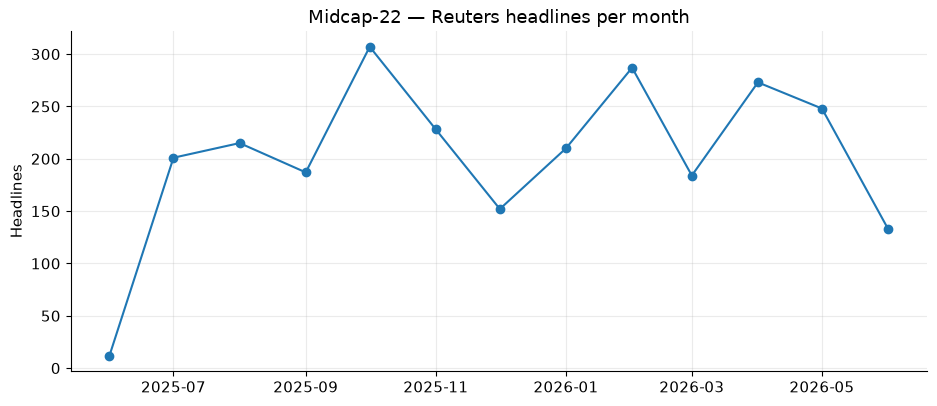

In [12]:
mid_mani = _load_json(PATHS["midcap_manifest"]) if PATHS["midcap_manifest"].exists() else {}
mid_counts = mid_mani.get("counts", {})
mid_cfg = mid_mani.get("config", {}).get("collection", {})
mid_summary = pd.Series(
    {
        "window_start": mid_cfg.get("start"),
        "window_end": mid_cfg.get("end"),
        "n_companies": len(mid_mani.get("config", {}).get("companies", [])),
        "articles": mid_counts.get("articles"),
        "eligible": mid_counts.get("eligible"),
        "text_quality": mid_counts.get("text_quality"),
        "fetch_story_bodies": mid_cfg.get("fetch_story_bodies"),
    },
    name="midcap_22_manifest",
)
display(mid_summary)

# Build a light frame from articles.jsonl without storing headline text.
mid_rows = []
with PATHS["midcap_articles"].open() as fh:
    for line in fh:
        obj = json.loads(line)
        mid_rows.append(
            {
                "revision_id": obj.get("revision_id"),
                "story_family_id": obj.get("story_family_id"),
                "version_created": obj.get("version_created"),
                "source_code": obj.get("source_code"),
                "matched_symbols": "|".join(obj.get("matched_symbols") or []),
                "text_quality": obj.get("text_quality"),
                "scoring_eligible": obj.get("scoring_eligible"),
            }
        )
mid = pd.DataFrame(mid_rows)
mid["version_created"] = pd.to_datetime(mid["version_created"], utc=True, format="ISO8601")
mid["date"] = mid["version_created"].dt.tz_convert("America/New_York").dt.normalize()
mid_firm = (
    mid.assign(symbol=mid["matched_symbols"].fillna("").str.split("|"))
    .explode("symbol")
    .loc[lambda d: d["symbol"].astype(str).str.len() > 0]
)
mid_firm_day = (
    mid_firm.groupby(["symbol", "date"], observed=True)
    .size()
    .rename("n_headlines")
    .reset_index()
)
mid_coverage = pd.Series(
    {
        "headline_rows": len(mid),
        "reuters_share": float((mid["source_code"] == "NS:RTRS").mean()),
        "unique_symbols": mid_firm["symbol"].nunique(),
        "firm_days": len(mid_firm_day),
        "median_n_per_firm_day": float(mid_firm_day["n_headlines"].median()),
        "share_firm_days_n1": float((mid_firm_day["n_headlines"] == 1).mean()),
        "date_min_ny": str(mid_firm["date"].min().date()),
        "date_max_ny": str(mid_firm["date"].max().date()),
        "n_calendar_days_with_news": mid_firm["date"].nunique(),
    },
    name="midcap_22_coverage",
)
display(mid_coverage)

fig, ax = plt.subplots()
monthly_mid = mid.groupby(mid["version_created"].dt.to_period("M")).size()
monthly_mid.index = monthly_mid.index.to_timestamp()
ax.plot(monthly_mid.index, monthly_mid.values, marker="o")
ax.set_title("Midcap-22 — Reuters headlines per month")
ax.set_ylabel("Headlines")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "midcap22_monthly.png", dpi=140)
plt.show()

Midcap is a clean Reuters-only, headline-only, 22-name / ~1y slice. Useful as
an out-of-universe robustness arm for Spine B, not as the primary panel: only
a few thousand headlines and mostly n=1 firm-days.

## 7. Prices and market benchmark

In [13]:
def _price_summary(path: Path, label: str) -> pd.Series:
    df = pd.read_csv(path)
    df["session_date"] = pd.to_datetime(df["session_date"])
    return pd.Series(
        {
            "file": path.name,
            "rows": len(df),
            "symbols": df["symbol"].nunique(),
            "session_min": str(df["session_date"].min().date()),
            "session_max": str(df["session_date"].max().date()),
            "n_sessions": df["session_date"].nunique(),
            "missing_adjusted_open": int(df["adjusted_open"].isna().sum())
            if "adjusted_open" in df.columns
            else int(df.get("open", pd.Series(dtype=float)).isna().sum()),
        },
        name=label,
    )


price_summaries = pd.DataFrame(
    [
        _price_summary(PATHS["prices_sector"], "sector_33"),
        _price_summary(PATHS["prices_midcap"], "midcap_22"),
        _price_summary(PATHS["prices_sp500"], "sp500"),
    ]
)
display(price_summaries)

# Overlap: news firm-days with a price on the next session is deferred to panel.py.
# Here we only check symbol sets.
sector_price_syms = set(pd.read_csv(PATHS["prices_sector"], usecols=["symbol"])["symbol"])
news_syms = set(firm_rows["symbol"].astype(str).unique())
print(
    f"sector-33 news symbols: {len(news_syms)}  "
    f"price symbols: {len(sector_price_syms)}  "
    f"news∩price: {len(news_syms & sector_price_syms)}  "
    f"news-only: {sorted(news_syms - sector_price_syms)[:10]}"
)

# Does the SP500 series cover the sector news window?
sp = pd.read_csv(PATHS["prices_sp500"])
sp["session_date"] = pd.to_datetime(sp["session_date"])
news_lo = firm_rows["date"].min().tz_convert(None)
news_hi = firm_rows["date"].max().tz_convert(None)
sp_cov = pd.Series(
    {
        "news_window_ny": f"{news_lo.date()} → {news_hi.date()}",
        "sp500_window": f"{sp['session_date'].min().date()} → {sp['session_date'].max().date()}",
        "sp500_covers_news_start": bool(sp["session_date"].min() <= news_lo),
        "sp500_covers_news_end": bool(sp["session_date"].max() >= news_hi),
    },
    name="benchmark_coverage",
)
display(sp_cov)

,file,rows,symbols,session_min,session_max,n_sessions,missing_adjusted_open
sector_33,lseg_us_sector_33_strategy_adjusted_open.csv,5148,33,2025-11-14,2026-07-01,156,0
midcap_22,lseg_us_midcap_22_strategy_adjusted_open.csv,5830,22,2025-06-20,2026-07-10,265,0
sp500,lseg_sp500_20250620_20260710.csv,265,1,2025-06-20,2026-07-10,265,0


sector-33 news symbols: 33  price symbols: 33  news∩price: 33  news-only: []


news_window_ny             2025-12-25 → 2026-06-25
sp500_window               2025-06-20 → 2026-07-10
sp500_covers_news_start                       True
sp500_covers_news_end                         True
Name: benchmark_coverage, dtype: object

## 8. FNSPID earnings calendar (LSEG gather)

Source: Workspace desktop pull via `scripts/fetch_fnspid_earnings_lseg.py`
into `final_experiments/data/earnings/` (licensed, gitignored). The
**quarterly** file is the Workstream 6 default. No headline text is printed.

present                                                                      True
source                               LSEG Workspace desktop session via lseg.data
window                               {'start': '2011-01-01', 'end': '2023-12-31'}
cohort_symbols                                                                574
quarterly_rows                                                              22883
all_matched_rows                                                            23139
title_filter_rejected_rows                                                   4268
symbols_with_quarterly_event                                                  490
symbols_with_zero_events                                                       84
share_cohort_covered                                                       0.8537
events_per_firm_median                                                       51.0
events_per_firm_p10                                                          33.0
events_per_firm_

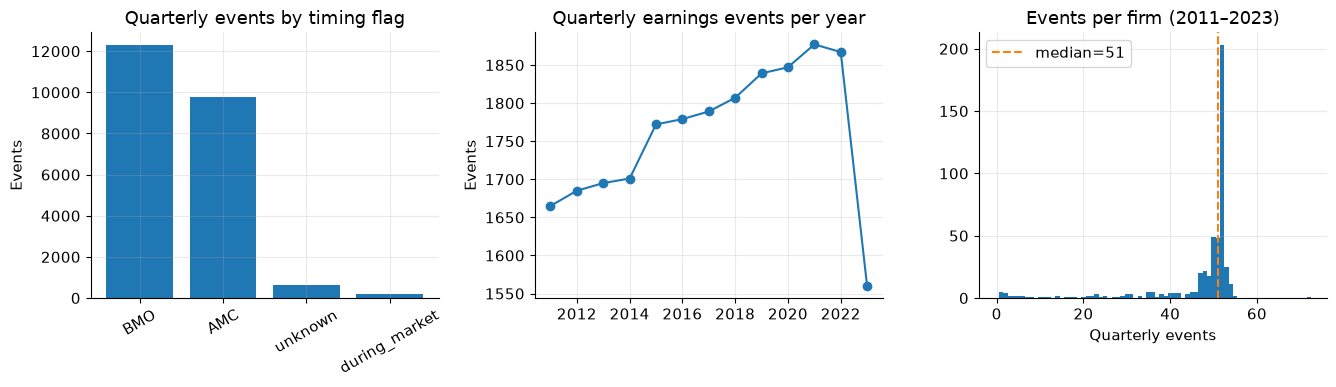

,share_of_firm_years
n_events,
0,0.215492
1-3,0.051997
4,0.718172
5+,0.014339


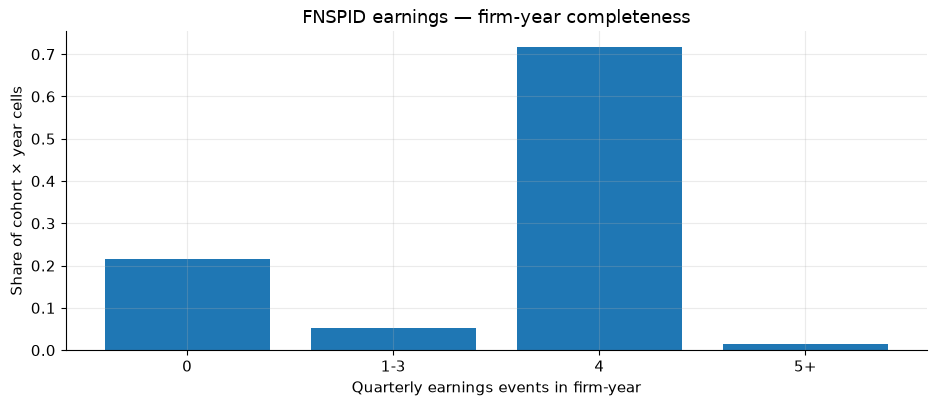

,rows
session_rule,
same_session,12505
next_session,10378


,symbols,raw_rows,rejected
class,,,
etf_fund,35,35,0
delisted,22,1125,1124
misresolved_non_equity,10,10,0
other_equity,10,451,449
foreign_or_adr,7,282,231


Zero-event symbols (84): {'etf_fund': 35, 'delisted': 22, 'misresolved_non_equity': 10, 'other_equity': 10, 'foreign_or_adr': 7}. ETF/fund absence is expected; the rest are coverage holes.
Recoverable equities fully dropped by the title filter (15): AEM, B, BG, BTI, BXP, CVE, DEO, GOLD, HIG, MDRX, NAT, SLB, SU, TTEK, VOD
Mis-resolved tickers mapped to futures/options roots (10): BK, FL, GOL, HA, HBI, MDC, NS, SOL, TRI, TUP


dup_symbol_report_date_rows                                                       17
weekend_report_dates                                                               8
during_market_same_session_rows                                                  202
during_market_note                 same_session for a midday release pulls pre-ne...
max_events_symbol                                                           ENB (72)
max_events_note                    multi-entity issuer (e.g. ENB family); dedupe ...
Name: earnings_dq_flags, dtype: object

In [14]:
earnings_summary: dict[str, Any] = {"present": False}
if not PATHS["earnings_quarterly"].exists():
    print("Earnings quarterly calendar missing — re-run scripts/fetch_fnspid_earnings_lseg.py")
else:
    earn_mani = (
        _load_json(PATHS["earnings_manifest"]) if PATHS["earnings_manifest"].exists() else {}
    )
    cohort = pd.read_csv(PATHS["fnspid_cohort_symbols"])
    cohort_syms = set(cohort["symbol"].astype(str))
    earn = pd.read_csv(PATHS["earnings_quarterly"])
    earn["report_date"] = pd.to_datetime(earn["report_date"])
    earn_all = (
        pd.read_csv(PATHS["earnings_all"])
        if PATHS["earnings_all"].exists()
        else earn
    )
    rejected_n = (
        sum(1 for _ in PATHS["earnings_rejected"].open("rb")) - 1
        if PATHS["earnings_rejected"].exists()
        else None
    )

    per_firm = earn.groupby("symbol").size()
    years = sorted(earn["report_date"].dt.year.unique())
    firm_year = (
        earn.assign(year=earn["report_date"].dt.year)
        .groupby(["symbol", "year"], observed=True)
        .size()
        .rename("n_events")
        .reset_index()
    )
    # Rough completeness: ~4 quarterly events per firm-year in a full window.
    fy_complete = firm_year.loc[firm_year["n_events"] >= 4, ["symbol", "year"]]
    n_possible_fy = len(cohort_syms) * len(years)

    covered = set(earn["symbol"].astype(str))
    zeros = sorted(cohort_syms - covered)
    timing = earn["timing_flag"].value_counts(dropna=False)
    status = earn["event_status"].value_counts(dropna=False)

    earnings_summary = {
        "present": True,
        "source": earn_mani.get("source", "LSEG Workspace"),
        "window": earn_mani.get("window"),
        "cohort_symbols": len(cohort_syms),
        "quarterly_rows": int(len(earn)),
        "all_matched_rows": int(len(earn_all)),
        "title_filter_rejected_rows": rejected_n,
        "symbols_with_quarterly_event": int(earn["symbol"].nunique()),
        "symbols_with_zero_events": len(zeros),
        "share_cohort_covered": round(len(covered) / max(len(cohort_syms), 1), 4),
        "events_per_firm_median": float(per_firm.median()),
        "events_per_firm_p10": float(per_firm.quantile(0.1)),
        "events_per_firm_p90": float(per_firm.quantile(0.9)),
        "firm_years_with_ge4_events": int(len(fy_complete)),
        "timing_flag_counts": timing.to_dict(),
        "bmo_share": round(float((earn["timing_flag"] == "BMO").mean()), 4),
        "amc_share": round(float((earn["timing_flag"] == "AMC").mean()), 4),
        "unknown_timing_share": round(float((earn["timing_flag"] == "unknown").mean()), 4),
        "confirmed_share": round(float((earn["event_status"] == "confirmed").mean()), 4),
        "fiscal_period_nonnull_share": round(float(earn["fiscal_period"].notna().mean()), 4),
        "report_date_min": str(earn["report_date"].min().date()),
        "report_date_max": str(earn["report_date"].max().date()),
        "zero_event_symbols_sample": zeros[:25],
    }
    display(pd.Series(earnings_summary, name="fnspid_earnings_quarterly"))

    # Coverage heatmap-style: events per firm-year distribution + annual totals.
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
    axes[0].bar(timing.index.astype(str), timing.values)
    axes[0].set_title("Quarterly events by timing flag")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("Events")

    annual = earn.groupby(earn["report_date"].dt.to_period("Y")).size()
    annual.index = annual.index.to_timestamp()
    axes[1].plot(annual.index, annual.values, marker="o")
    axes[1].set_title("Quarterly earnings events per year")
    axes[1].set_ylabel("Events")

    axes[2].hist(per_firm.values, bins=range(0, int(per_firm.max()) + 2), align="left")
    axes[2].axvline(per_firm.median(), color="C1", ls="--", label=f"median={per_firm.median():.0f}")
    axes[2].set_title("Events per firm (2011–2023)")
    axes[2].set_xlabel("Quarterly events")
    axes[2].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "earnings_timing_and_coverage.png", dpi=140)
    plt.show()

    # Firm-year intensity: share of firm-years with 0, 1–3, 4, 5+ events.
    fy_pivot = firm_year.pivot(index="symbol", columns="year", values="n_events").reindex(
        sorted(cohort_syms)
    )
    fy_long = (
        fy_pivot.fillna(0)
        .stack()
        .rename("n_events")
        .reset_index()
    )
    bins = pd.cut(
        fy_long["n_events"],
        bins=[-0.1, 0, 3, 4, 20],
        labels=["0", "1-3", "4", "5+"],
    )
    fy_bin = bins.value_counts(normalize=True).sort_index()
    display(fy_bin.rename("share_of_firm_years").to_frame())

    fig, ax = plt.subplots()
    ax.bar(fy_bin.index.astype(str), fy_bin.values)
    ax.set_ylabel("Share of cohort × year cells")
    ax.set_xlabel("Quarterly earnings events in firm-year")
    ax.set_title("FNSPID earnings — firm-year completeness")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "earnings_firm_year_completeness.png", dpi=140)
    plt.show()

    # Session-rule mix (what the panel builder will actually use).
    if "session_rule" in earn.columns:
        display(earn["session_rule"].value_counts(dropna=False).rename("rows").to_frame())

    # --- Zero-event symbols: real classification, not "mostly ETFs" ----------
    # Classify each zero-event symbol from the RIC map's DocumentTitle, and
    # cross-reference how many raw/rejected rows it produced.
    ric_map = pd.read_csv(PATHS["earnings_ric_map"])
    raw_events = pd.read_csv(PATHS["earnings_raw"])
    rejected = (
        pd.read_csv(PATHS["earnings_rejected"])
        if PATHS["earnings_rejected"].exists()
        else pd.DataFrame(columns=["symbol"])
    )
    ric_to_sym = dict(zip(ric_map["ric"].astype(str), ric_map["symbol"].astype(str), strict=False))
    raw_events["symbol"] = raw_events["Instrument"].astype(str).map(ric_to_sym)
    raw_counts = raw_events.groupby("symbol").size()
    rej_counts = rejected.groupby("symbol").size()

    def _classify_zero_symbol(doc_title: object) -> str:
        t = str(doc_title).lower()
        if "etf" in t or "fund" in t:
            return "etf_fund"
        if "future" in t or "commodity" in t or re.search(r"\boption\b", t):
            return "misresolved_non_equity"
        if "delisted" in t:
            return "delisted"
        if "depository receipt" in t or re.search(r"\b(p\.?l\.?c|s\.?a\.?|n\.?v\.?|a\.?g\.?|ltd)\b", t):
            return "foreign_or_adr"
        return "other_equity"

    zero_rows = []
    for sym in zeros:
        doc = ric_map.loc[ric_map["symbol"] == sym, "document_title"]
        zero_rows.append(
            {
                "symbol": sym,
                "class": _classify_zero_symbol(doc.iloc[0] if len(doc) else ""),
                "raw_rows": int(raw_counts.get(sym, 0)),
                "rejected_rows": int(rej_counts.get(sym, 0)),
            }
        )
    zero_class = pd.DataFrame(zero_rows)
    zero_breakdown = (
        zero_class.groupby("class")
        .agg(symbols=("symbol", "size"), raw_rows=("raw_rows", "sum"), rejected=("rejected_rows", "sum"))
        .sort_values("symbols", ascending=False)
    )
    display(zero_breakdown)

    # Equities with a full raw history that the issuer-title filter dropped
    # entirely — recoverable coverage holes, not "no earnings".
    recoverable = zero_class.loc[
        (zero_class["class"].isin(["other_equity", "foreign_or_adr"]))
        & (zero_class["raw_rows"] >= 10)
    ]
    print(
        f"Zero-event symbols ({len(zeros)}): {zero_breakdown['symbols'].to_dict()}. "
        "ETF/fund absence is expected; the rest are coverage holes."
    )
    print(
        "Recoverable equities fully dropped by the title filter "
        f"({len(recoverable)}): {', '.join(recoverable['symbol'])}"
    )
    print(
        "Mis-resolved tickers mapped to futures/options roots "
        f"({int((zero_class['class'] == 'misresolved_non_equity').sum())}): "
        f"{', '.join(zero_class.loc[zero_class['class'] == 'misresolved_non_equity', 'symbol'])}"
    )
    earnings_summary["zero_event_breakdown"] = {
        k: int(v) for k, v in zero_breakdown["symbols"].items()
    }
    earnings_summary["recoverable_equity_gaps"] = recoverable["symbol"].tolist()

    # --- Calendar data-quality flags for the panel builder -------------------
    earn_dups = int(earn.duplicated(subset=["symbol", "report_date"]).sum())
    weekend_dates = int((earn["report_date"].dt.dayofweek >= 5).sum())
    during_mkt = earn.loc[earn["timing_flag"] == "during_market"]
    top_symbol = earn.groupby("symbol").size().idxmax()
    top_symbol_n = int(earn.groupby("symbol").size().max())
    dq_flags = pd.Series(
        {
            "dup_symbol_report_date_rows": earn_dups,
            "weekend_report_dates": weekend_dates,
            "during_market_same_session_rows": int((during_mkt["session_rule"] == "same_session").sum()),
            "during_market_note": (
                "same_session for a midday release pulls pre-news trading into the "
                "event window under open-to-open returns — declare a rule in 01_panel"
            ),
            "max_events_symbol": f"{top_symbol} ({top_symbol_n})",
            "max_events_note": "multi-entity issuer (e.g. ENB family); dedupe on (symbol, report_date)",
        },
        name="earnings_dq_flags",
    )
    display(dq_flags)
    earnings_summary["dq_flags"] = {k: v for k, v in dq_flags.items() if not k.endswith("_note")}

### Earnings calendar quality read

- **Usable for WS6 on FNSPID.** 490 of 574 cohort symbols have quarterly
  dates; median events/firm = 51 over 2011–2023 (~4/year; p90 = 52).
- **Timing is mostly known.** BMO and AMC dominate; unknown-time rows get the
  conservative next-session rule. 202 `during_market` rows map to
  `same_session` — under open-to-open returns that pulls pre-news trading
  into the event window, so the panel needs a declared rule for them.
- **Gaps are NOT "mostly ETFs."** Of the 84 zero-event symbols only 35 are
  ETF/fund (genuinely no earnings) and 22 are delisted/acquired names
  (expected attrition for a 2011–2023 cohort). The remaining 27 are
  *recoverable coverage holes*: 10 tickers mis-resolved by LSEG symbol
  conversion onto futures/options roots (BK, FL, GOL, HA, HBI, MDC, NS, SOL,
  TRI, TUP), and 17 equity/ADR names dropped by the issuer-title filter, 15
  of which have a full raw RES history — mostly name-change /
  parenthetical-phrase failures (BXP = "Boston Properties" titles, HIG =
  "Hartford Financial Services", TTEK, SU; also AEM, BTI, DEO, VOD, SLB…).
  The fetch script's phrase rule has been hardened and symbol conversion now
  flags non-equity resolutions; re-fetch when Workspace is available to
  close these holes.
- **Panel-builder flags.** 17 duplicated (symbol, report_date) rows and
  multi-entity issuers (ENB, 72 events) — dedupe on (symbol, report_date) at
  panel build. 8 weekend report_dates.
- **Still open.** Validate against `earnings_guidance` headlines; extend to
  LSEG-only universes if those become primary; EPS actual/consensus not pulled.

## 9. Cross-spine comparison (do not pool)

In [15]:
comparison = pd.DataFrame(
    [
        {
            "spine": "A FNSPID (plan / Gate 1 revised)",
            "firms": 574,
            "approx_events": 1_641_283,
            "window": "2011–2023",
            "bodies": "No (scraped headlines)",
            "publisher_id": "site string",
            "precise_timestamps": "Rare (~138k of 9.0M symbol rows)",
            "on_disk_ready": bool(PATHS["fnspid_all_external"].exists()),
            "enough_date_clusters_for_inference": True,
            "enough_for_learned_thresholds": True,
        },
        {
            "spine": "B LSEG sector-33",
            "firms": int(coverage["unique_symbols_in_news"]),
            "approx_events": int(coverage["firm_associations"]),
            "window": f"{coverage['date_min_ny']} → {coverage['date_max_ny']}",
            "bodies": "Partial Reuters only",
            "publisher_id": "source_code (2,854)",
            "precise_timestamps": "Yes (UTC version_created)",
            "on_disk_ready": True,
            "enough_date_clusters_for_inference": "Borderline (~85–120 sessions)",
            "enough_for_learned_thresholds": False,
        },
        {
            "spine": "B LSEG midcap-22",
            "firms": int(mid_coverage["unique_symbols"]),
            "approx_events": int(mid_coverage["headline_rows"]),
            "window": f"{mid_coverage['date_min_ny']} → {mid_coverage['date_max_ny']}",
            "bodies": "No (headline-only by config)",
            "publisher_id": "NS:RTRS only",
            "precise_timestamps": "Yes",
            "on_disk_ready": True,
            "enough_date_clusters_for_inference": "Weak",
            "enough_for_learned_thresholds": False,
        },
    ]
)
display(comparison)
comparison.to_csv(OUTPUT_DIR / "spine_comparison.csv", index=False)

,spine,firms,approx_events,window,bodies,publisher_id,precise_timestamps,on_disk_ready,enough_date_clusters_for_inference,enough_for_learned_thresholds
0,A FNSPID (plan / Gate 1 revised),574,1641283,2011–2023,No (scraped headlines),site string,Rare (~138k of 9.0M symbol rows),True,True,True
1,B LSEG sector-33,33,739242,2025-12-25 → 2026-06-25,Partial Reuters only,"source_code (2,854)",Yes (UTC version_created),True,Borderline (~85–120 sessions),False
2,B LSEG midcap-22,22,2637,2025-06-26 → 2026-06-25,No (headline-only by config),NS:RTRS only,Yes,True,Weak,False


## 10. Decision checklist — do we need more data?

In [16]:
decisions = pd.DataFrame(
    [
        {
            "decision": "Primary spine",
            "recommendation": (
                "Prefer FNSPID (Spine A) if the closing RQ needs statistical power, "
                "aggregation comparisons, surprise demeaning, or learned thresholds. "
                "Prefer LSEG sector-33 (Spine B) if the RQ needs publisher metadata, "
                "precise timing, or body text. Do not average across spines."
            ),
            "action_if_yes": "Write one-paragraph justification into plan.html (Gate F1).",
        },
        {
            "decision": "Restore / re-verify FNSPID?",
            "recommendation": (
                "Archives are present and size-matched. Re-hash before promoting any "
                "FNSPID result into the dissertation; Gate 2 price validation still open."
            ),
            "action_if_yes": "Re-verify upstream SHA-256; confirm 574-firm cohort still reproduces.",
        },
        {
            "decision": "Collect a wider LSEG universe?",
            "recommendation": (
                "Only if Spine B is primary AND you need more date clusters or firms. "
                "Sector-33 alone is tight for inference; midcap adds little mass. "
                "If collecting: Reuters-only allowlist, budget for 5/sec and 10k/day, "
                "and finish the unfetched Reuters bodies first."
            ),
            "action_if_yes": "Draft new config; size request budget; do not expand casually.",
        },
        {
            "decision": "Finish sector-33 Reuters body backfill?",
            "recommendation": (
                "Yes if body-conditioned arms matter. Manifests still show thousands of "
                "Reuters targets without a clean scoring-eligible body."
            ),
            "action_if_yes": "Resume fetch-lseg-news with existing checkpoints.",
        },
        {
            "decision": "Acquire earnings calendar?",
            "recommendation": (
                "FNSPID 2011–2023 quarterly calendar is on disk via LSEG "
                f"({'present' if PATHS['earnings_quarterly'].exists() else 'MISSING'}). "
                "Still needed: headline validation, optional LSEG-name extension, "
                "and pre/event/post window definition in the panel."
            ),
            "action_if_yes": "Validate against earnings_guidance; wire into panel.py.",
        },
        {
            "decision": "Build explicit sector table?",
            "recommendation": "Yes — cheap and blocks per-sector thresholds / sector demeaning.",
            "action_if_yes": "One CSV: symbol → sector from the sector-33 config + midcap mapping.",
        },
        {
            "decision": "Human audit labels?",
            "recommendation": (
                "Yes before trusting story filters or event-type conditioning. "
                "Templates exist; labels do not. Target 150–200 stratified stories."
            ),
            "action_if_yes": "Label filter precision sample (WS2) and event-type sample (WS5).",
        },
        {
            "decision": "Is current LSEG quality model-ready?",
            "recommendation": (
                "Structurally yes for headline panels; not yet for company-targeted "
                "sentiment without a relevance screen. Quality audit + score flags both "
                "say RIC association overstates direct company news."
            ),
            "action_if_yes": "Keep explicit_target / contextual filters in the panel builder.",
        },
    ]
)
display(decisions)
decisions.to_csv(OUTPUT_DIR / "decision_checklist.csv", index=False)

,decision,recommendation,action_if_yes
0,Primary spine,Prefer FNSPID (Spine A) if the closing RQ need...,Write one-paragraph justification into plan.ht...
1,Restore / re-verify FNSPID?,Archives are present and size-matched. Re-hash...,Re-verify upstream SHA-256; confirm 574-firm c...
2,Collect a wider LSEG universe?,Only if Spine B is primary AND you need more d...,Draft new config; size request budget; do not ...
3,Finish sector-33 Reuters body backfill?,Yes if body-conditioned arms matter. Manifests...,Resume fetch-lseg-news with existing checkpoints.
4,Acquire earnings calendar?,FNSPID 2011–2023 quarterly calendar is on disk...,Validate against earnings_guidance; wire into ...
5,Build explicit sector table?,Yes — cheap and blocks per-sector thresholds /...,One CSV: symbol → sector from the sector-33 co...
6,Human audit labels?,Yes before trusting story filters or event-typ...,Label filter precision sample (WS2) and event-...
7,Is current LSEG quality model-ready?,Structurally yes for headline panels; not yet ...,Keep explicit_target / contextual filters in t...


## 11. Bottom line

1. **We already have two usable spines on disk.** FNSPID archives are present;
   both LSEG collections and their price panels are present.
2. **Earnings calendar for FNSPID is gathered** (LSEG RES, quarterly file
   recommended). Remaining cheap blockers: sector table and human audit labels.
3. **Quality is mixed, not fatal.** FNSPID: huge but date-only and source-regime
   unstable; no bodies. LSEG sector-33: rich metadata and precise times, but
   relevance noise, incomplete Reuters bodies, and a short evaluation window.
   Midcap: clean but thin.
4. **Need-more ranking (highest leverage first).**
   - Explicit sector table (cheap; unblocks threshold / demeaning arms).
   - Human audit labels (blocks claiming filter/event-type precision).
   - Earnings validation + optional LSEG-universe extension (WS6).
   - Optional: finish Reuters body backfill / widen LSEG — only if Spine B is primary.
5. **Next notebook.** `01_panel` should build one firm-day panel on the chosen
   primary spine, with an attrition table and coverage figure, before any scoring.

In [17]:
# Persist a compact machine-readable summary for the plan / handoff.
summary = {
    "generated_by": "final_experiments/00_data_inventory",
    "assets_missing": missing,
    "fnspid_archives_size_matched": bool(
        fnspid_archive_check and all(r["size_match"] for r in fnspid_archive_check)
    ),
    "sector_33": coverage.to_dict(),
    "sector_33_score_join": {
        "raw_key_overlap": round(raw_key_overlap, 4),
        "recomputed_key_overlap": round(repaired_overlap, 4),
        "panel_rule": "recompute score-side key as sha256(normalize_headline(headline))",
    },
    "midcap_22": mid_coverage.to_dict(),
    "fnspid_earnings": earnings_summary,
    "must_gather": gather.loc[gather["need_more"] == True, "item"].tolist(),  # noqa: E712
    "decision_dependent_gather": gather.loc[gather["need_more"].isna(), "item"].tolist(),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(f"wrote {OUTPUT_DIR / 'summary.json'}")
print("must gather:", summary["must_gather"])
print(
    "earnings covered:",
    earnings_summary.get("symbols_with_quarterly_event"),
    "/",
    earnings_summary.get("cohort_symbols"),
)

wrote /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/00_data_inventory/summary.json
must gather: ['Sector / industry mapping', 'Human audit labels']
earnings covered: 490 / 574
